# exp-gs-002-01 — H-A Logistic 3-seed 기준 실험

목적: Hongju H-A(`G+B+V+T+R+A`)를 기준점으로 재측정한다. Logistic `lbfgs`, `C=0.07`, `max_iter=2000`, `class_weight=balanced`, Stratified 5-fold를 유지하며 seed 42/2024/777을 별도 프로세스로 실행한다.

- test는 fit/통계/피처선택에 사용하지 않는다.
- test NaN 237개는 mutation/event로 세지 않는다.
- 수렴 경고, feature 수, runtime, OOF Macro F1, 클래스별 F1을 기록한다.

In [1]:
from pathlib import Path
import subprocess
import sys
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

ROOT = Path.cwd()
while not (ROOT / 'data' / 'raw' / 'train.csv').exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError('프로젝트 루트에서 실행하세요.')
    ROOT = ROOT.parent
EDA_DIR = ROOT / 'experiments' / 'gs' / 'notebooks' / 'eda_pre_002'
RUNNER = EDA_DIR / 'common' / 'exp-gs-002-memory-safe.py'
RESULT_DIR = EDA_DIR / 'result'
RUN_ID = 'exp-gs-002-01'
SEEDS = (42, 2024, 777)
assert RUNNER.exists()
RESULT_DIR.mkdir(exist_ok=True)
print({'runner': RUNNER, 'result_dir': RESULT_DIR, 'seeds': SEEDS})

{'runner': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/eda_pre_002/common/exp-gs-002-memory-safe.py'), 'result_dir': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/eda_pre_002/result'), 'seeds': (42, 2024, 777)}


/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 사용자가 True로 바꿨을 때만 3-seed 실험을 실행합니다.
# seed 단위 tqdm과 common runner 내부의 gene-cache/fold tqdm이 모두 표시됩니다.
RUN_EXPERIMENT = True

if RUN_EXPERIMENT:
    for seed in tqdm(SEEDS, desc=f'{RUN_ID} | 3-seed 실행', unit='seed'):
        command = [
            sys.executable, str(RUNNER),
            '--run-id', RUN_ID,
            '--candidate', 'H-A',
            '--model', 'logistic',
            '--seed', str(seed),
        ]
        completed = subprocess.run(command, cwd=ROOT)
        if completed.returncode != 0:
            raise RuntimeError(f'seed {seed} 실행 실패: {completed.returncode}')


row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 391.34it/s]
H-A | logistic | seed 42: 100%|██████████| 5/5 [04:24<00:00, 52.81s/it]


{
  "experiment_id": "H-A",
  "model": "logistic",
  "seed": 42,
  "oof_macro_f1": 0.42638642943928645,
  "oof_accuracy": 0.4155781325592646,
  "fold_macro_f1_mean": 0.42514238977228064,
  "fold_macro_f1_std": 0.0069429165639570585,
  "feature_count_mean": 8205.2,
  "runtime_seconds": 264.13481408299776,
  "convergence_warning_count": 5,
  "leakage_check": true,
  "nan_as_mutation_count": 0
}


row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 397.88it/s]
H-A | logistic | seed 2024: 100%|██████████| 5/5 [04:29<00:00, 53.86s/it]


{
  "experiment_id": "H-A",
  "model": "logistic",
  "seed": 2024,
  "oof_macro_f1": 0.43518291387482166,
  "oof_accuracy": 0.4225124979841961,
  "fold_macro_f1_mean": 0.4347227919121913,
  "fold_macro_f1_std": 0.009712691580307051,
  "feature_count_mean": 8205.0,
  "runtime_seconds": 269.3770892499997,
  "convergence_warning_count": 4,
  "leakage_check": true,
  "nan_as_mutation_count": 0
}


row-local mutation cache: 100%|██████████| 4384/4384 [00:10<00:00, 401.30it/s]
H-A | logistic | seed 777: 100%|██████████| 5/5 [04:20<00:00, 52.06s/it]


{
  "experiment_id": "H-A",
  "model": "logistic",
  "seed": 777,
  "oof_macro_f1": 0.43000667617973076,
  "oof_accuracy": 0.4210611191743267,
  "fold_macro_f1_mean": 0.42920652847002394,
  "fold_macro_f1_std": 0.009171112297258817,
  "feature_count_mean": 8200.4,
  "runtime_seconds": 260.4077334169997,
  "convergence_warning_count": 5,
  "leakage_check": true,
  "nan_as_mutation_count": 0
}


exp-gs-002-01 | 3-seed 실행: 100%|██████████| 3/3 [14:30<00:00, 290.23s/seed]


,experiment_id,model,seed,oof_macro_f1,oof_accuracy,fold_macro_f1_mean,fold_macro_f1_std,feature_count_mean,runtime_seconds,convergence_warning_count,leakage_check,nan_as_mutation_count
0,H-A,logistic,42,0.426386,0.415578,0.425142,0.006943,8205.2,264.134814,5,True,0
2,H-A,logistic,777,0.430007,0.421061,0.429207,0.009171,8200.4,260.407733,5,True,0
1,H-A,logistic,2024,0.435183,0.422512,0.434723,0.009713,8205.0,269.377089,4,True,0


,experiment_id,model,seed_count,oof_macro_f1_mean,oof_macro_f1_std,oof_accuracy_mean,feature_count_mean,runtime_seconds_mean,convergence_warning_count,leakage_check,nan_as_mutation_count
0,H-A,logistic,3,0.430525,0.004421,0.419717,8203.533333,264.639879,14,True,0


,class,class_f1_mean,class_f1_std,support
20,SKCM,0.868097,0.004276,276.0
0,ACC,0.769861,0.009770,72.0
4,COAD,0.734978,0.009290,223.0
23,THCA,0.685160,0.003465,324.0
25,UCEC,0.553585,0.006774,198.0
22,TGCT,0.543085,0.017431,124.0
14,LUSC,0.536124,0.008418,178.0
21,STES,0.502470,0.016193,379.0
2,BRCA,0.478759,0.001168,786.0
11,LGG,0.476937,0.006292,229.0


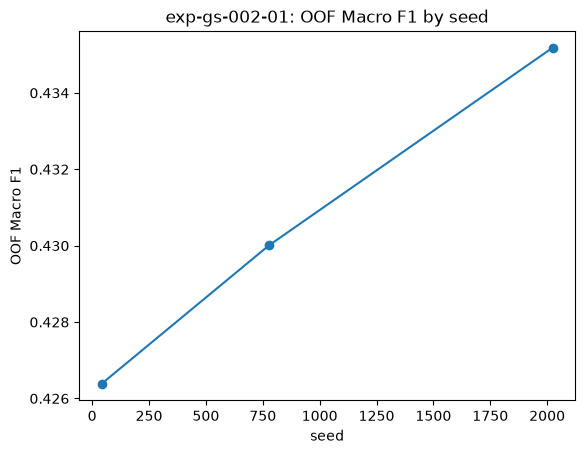

In [5]:
oof_files = [RESULT_DIR / f'{RUN_ID}_H-A_logistic_seed{seed}_oof.csv' for seed in SEEDS]
class_files = [RESULT_DIR / f'{RUN_ID}_H-A_logistic_seed{seed}_class_f1.csv' for seed in SEEDS]
if all(path.exists() for path in oof_files + class_files):
    runs = pd.concat([pd.read_csv(path) for path in oof_files], ignore_index=True).sort_values('seed')
    summary = (
    runs.groupby(['experiment_id', 'model'], as_index=False)
    .agg(
        seed_count=('seed', 'nunique'),
        oof_macro_f1_mean=('oof_macro_f1', 'mean'),
        oof_macro_f1_std=('oof_macro_f1', 'std'),
        oof_accuracy_mean=('oof_accuracy', 'mean'),
        feature_count_mean=('feature_count_mean', 'mean'),
        runtime_seconds_mean=('runtime_seconds', 'mean'),
        convergence_warning_count=('convergence_warning_count', 'sum'),
        leakage_check=('leakage_check', 'all'),
        nan_as_mutation_count=('nan_as_mutation_count', 'max'),
    )
)
    summary_path = RESULT_DIR / f'{RUN_ID}_3seed_summary.csv'
    summary.to_csv(summary_path, index=False)
    class_runs = pd.concat([pd.read_csv(path).assign(seed=seed) for path, seed in zip(class_files, SEEDS)], ignore_index=True)
    class_summary = class_runs.groupby('class', as_index=False).agg(class_f1_mean=('f1-score', 'mean'), class_f1_std=('f1-score', 'std'), support=('support', 'first'))
    class_summary.to_csv(RESULT_DIR / f'{RUN_ID}_class_f1_3seed_summary.csv', index=False)
    display(runs)
    display(summary)
    display(class_summary.sort_values('class_f1_mean', ascending=False).head(10))
    ax = runs.plot(x='seed', y='oof_macro_f1', marker='o', legend=False, title='exp-gs-002-01: OOF Macro F1 by seed')
    ax.set_ylabel('OOF Macro F1')
    plt.show()
else:
    missing = [path.name for path in oof_files + class_files if not path.exists()]
    print('3-seed 결과가 아직 완성되지 않았습니다:', missing)